# APRENDIZAJE AUTOMÁTICO
# Práctica 1: Regresión
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 02-02-2026
---



## Configuración

In [3]:
%matplotlib inline
# try:
#   from google.colab import drive
#   print("Trabajando en Colab")
#   drive.mount('/content/drive')                # Monta tu google drive
#   Path = '/content/drive/MyDrive/Aprendizaje/' # Directorio donde guardas los ficheros de datos
# except:
print("Trabajando en local")
import os
Path = os.getcwd() + "/"  # Directorio donde guardas los ficheros de datos


Trabajando en local


---
## 0. Visualización de datos

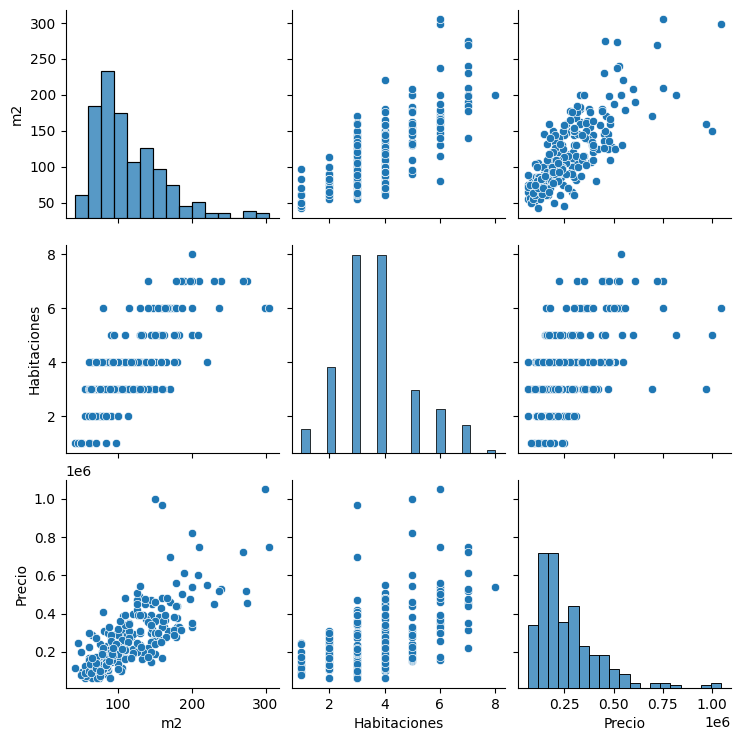

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

# Leer los ficheros de datos y pasarlos a matrices de numpy
pisos_train = pd.read_csv(Path+'PisosTrain.csv', sep = ";")
x1_train = pisos_train["m2"].to_numpy().reshape(-1, 1)
x2_train = pisos_train["Habitaciones"].to_numpy().reshape(-1, 1)
y_train  = pisos_train["Precio"].to_numpy()

pisos_test  = pd.read_csv(Path+'PisosTest.csv',  sep = ";")
x1_test = pisos_test["m2"].to_numpy().reshape(-1, 1)
x2_test = pisos_test["Habitaciones"].to_numpy().reshape(-1, 1)
y_test  = pisos_test["Precio"].to_numpy()

# Mostrar los datos de entrenamiento
seaborn.pairplot(pisos_train)
plt.show()

# Análisis de datos de viviendas.

## Conclusiones generales

- Existe una **relación positiva clara entre los metros cuadrados (m²) y el precio**.
- A mayor tamaño de la vivienda, **mayor precio**, siguiendo una tendencia aproximadamente lineal.
- El número de **habitaciones también influye en el precio**, pero **menos que los m²**.
- Los **m² y las habitaciones están correlacionados**, por lo que parte de la información es redundante.

---

## Datos anómalos (outliers)

- Se observan **viviendas muy caras** (precios cercanos o superiores al millón) que:
  - No siguen la tendencia general.
  - Pueden distorsionar la regresión lineal.
- Existen **pisos con muchos m² pero precios relativamente bajos** y viceversa.
- La variabilidad del precio **aumenta con los m²** (heterocedasticidad).

**Conclusión:**  
Los outliers pueden afectar negativamente al ajuste del modelo y deberían analizarse o tratarse.

---

## Análisis por variable

### m²
- Distribución dispar (muchos pisos medianos, pocos muy grandes).
- Es la **variable explicativa más importante**.
- Presenta una relación casi lineal con el precio.

### Habitaciones
- Relación positiva con el precio, pero con **mucha dispersión**.
- Aporta información adicional, pero limitada.

### Precio
- Distribución sesgada a la derecha.
- Presencia clara de valores extremos.

---

# 1. Métricas

Aquí explico qué métricas voy a usar y por qué.

## Uso de métricas.
### Se van a usar varias métricas para determinar que modelos son mejores, vamos a usar principalmente 2:
#### $R^2$: Lo vamos a usar porque es una buena métrica para cualquier tipo de dataset.
#### MAE: Lo vamos a usar porque nuestro dataset tiene datos espúreos, y MAE es una buena medida ante estos datos, ya que nos dá la media de error (€) de nuestro modelo.
#### MRE / MAPE: Lo vamos a usar para ver en cuanto % de media se va nuestra predicción del precio, ya que el número solo de € puede no ser significativo dependiendo de los datos de los pisos que tengamos.

In [8]:
import sklearn
## aquí programo una función para calcularlas
def calcular_metricas(regresor,x_train, y_train, x_test, y_test):
    r2_test = sklearn.metrics.r2_score(y_test, regresor.predict(x_test))
    mae_test = sklearn.metrics.mean_absolute_error(y_test, regresor.predict(x_test))
    mre_test = sklearn.metrics.mean_absolute_percentage_error(y_test, regresor.predict(x_test)) * 100
    print("Métricas de evaluación en el conjunto de test:")
    print(f"R2 test:  {r2_test:.4f}")
    print(f"MAE test:  {mae_test:.2f}€")
    print(f"MRE test:  {mre_test:.2f} %")
    r2_train = sklearn.metrics.r2_score(y_train, regresor.predict(x_train))
    mae_train = sklearn.metrics.mean_absolute_error(y_train, regresor.predict(x_train))
    mre_train = sklearn.metrics.mean_absolute_percentage_error(y_train, regresor.predict(x_train)) * 100
    print("Métricas de control en el conjunto de entrenamiento:")
    print(f"R2 train: {r2_train:.4f}")
    print(f"MAE train: {mae_train:.2f}€")
    print(f"MRE train: {mre_train:.2f} %")

----
# 2. Regresión Monovariable

## Explicación y fuentes
### Explicación
Explicación aqui
### Fuentes
[Documentación de Scikit-Learn para la LinearRegression (ESP)](https://qu4nt.github.io/sklearn-doc-es/modules/linear_model.html)

[Enlace a Doc de ejemplo de Scikit-Learn (ESP)](https://qu4nt.github.io/sklearn-doc-es/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py)

Ecuacion: Precio = 2608.2094 * Superficie + -34313.3880
Métricas de evaluación en el conjunto de test:
R2 test:  0.4609
MAE test:  63936.47
MRE test:  27.44 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.5835
MAE train: 69534.93
MRE train: 30.09 %


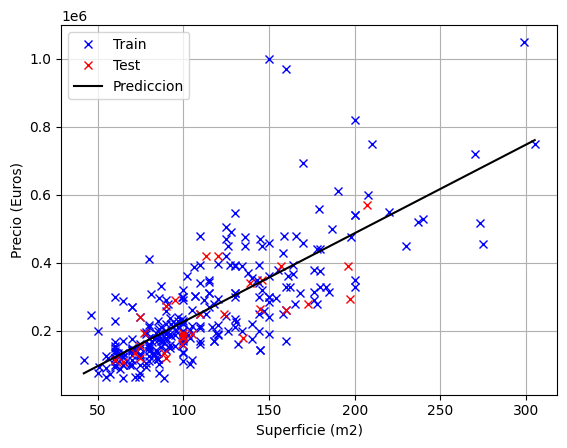

In [ ]:
import sklearn

# Ejemplo de dibujo de un atributo y una prediccion inventada
x1_grid = np.linspace(np.min(x1_train), np.max(x1_train), 100).reshape(-1, 1)


regresor = sklearn.linear_model.LinearRegression()
regresor = regresor.fit(x1_train, y_train)

# Ecuacion de la recta de prediccion
m = float(regresor.coef_[0])
b = float(regresor.intercept_)
print(f"Ecuacion: Precio = {m:.4f} * Superficie + {b:.4f}")
y_pred = regresor.predict(x1_grid)
calcular_metricas(regresor, x1_train, y_train, x1_test, y_test)

plt.figure()
plt.plot(x1_train, y_train, 'bx', label='Train')
plt.plot(x1_test, y_test,  'rx', label='Test')
plt.plot(x1_grid, y_pred, 'k-', label='Prediccion')
plt.xlabel('Superficie (m2)')
plt.ylabel('Precio (Euros)')
plt.legend()
plt.grid()
plt.show()

## Evaluación del modelo
Este modelo tiene un $R^2$ con los datos de test de 0.46, por lo que tiene bastante capacidad de mejora para acercarse al 1.

Respecto a nuestra otra medida de error MAE, podemos observar que nos vamos en 64.000€ de media en nuestras predicciones, lo cual es bastante, espcecialmente teniendo en cuenta que el MRE es un 27%


# 3. Regresión Multivariable


## Explicación y fuentes
### Explicación
---
### Fuentes
[Pipe / Pipeline Diapositivas Temario T1 P26](https://moodle.unizar.es/add/pluginfile.php/16097540/mod_resource/content/13/1.Regresio%CC%81n.pdf)
- Multivariable polinómica:
    - [PolynomialFeatures (Scikit-Learn)[ESP]](https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#sklearn.preprocessing.PolynomialFeatures)
- Multivariable preprocesado:
    - [StandarScaler() Diapositivas Temario T1 P26](https://moodle.unizar.es/add/pluginfile.php/16097540/mod_resource/content/13/1.Regresio%CC%81n.pdf)
- Multivariable descenso gradiante estocástico:
    - [SGDRegressor (Scikit-Learn)[ESP]](https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor)
- Multivariable robusta con coste de Huber:
    - [KFold - Logspace Diapositivas Temario T2 P27](https://moodle.unizar.es/add/pluginfile.php/16097545/mod_resource/content/10/2.Regularizacio%CC%81n.pdf)
    - [HuberRegressor (Scikit-Learn)[ESP]](https://qu4nt.github.io/sklearn-doc-es/modules/linear_model.html#huber-regression)

## Regresión multivariable polinómica.

Uso la función de **PolynomialFeatures** que ya estaba propuesta en la plantilla de la práctica, es útil para ver interrelaciones entre las variables, y ver si están correlacionadas.

La compararemos con el modelo multivariable lineal más adelante.

In [45]:
import sklearn

poly = sklearn.preprocessing.PolynomialFeatures(degree=2, include_bias=False)

X_train = np.hstack((x1_train, x2_train))
X_test = np.hstack((x1_test, x2_test))

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

reg_poly = sklearn.linear_model.LinearRegression().fit(X_train_poly, y_train)

print(f"Ecuacion polinomial: Precio = {reg_poly.coef_[0]:.4f} * Superficie + {reg_poly.coef_[1]:.4f} * Habitaciones + {reg_poly.coef_[2]:.4f} * Superficie^2 + {reg_poly.coef_[3]:.4f} * Superficie*Habitaciones + {reg_poly.coef_[4]:.4f} * Habitaciones^2 + {reg_poly.intercept_:.4f}")
calcular_metricas(reg_poly, X_train_poly, y_train, X_test_poly, y_test)

Ecuacion polinomial: Precio = 3507.2569 * Superficie + -25163.6430 * Habitaciones + 4.6381 * Superficie^2 + -406.8386 * Superficie*Habitaciones + 6990.9787 * Habitaciones^2 + -31324.5909
Métricas de evaluación en el conjunto de test:
R2 test:  0.5016
MAE test:  58375.64€
MRE test:  23.96 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.5985
MAE train: 69426.13€
MRE train: 29.78 %


## Regresión multivariable polinomial con preprocesado de variables.
Vamos a intentar tener en cuenta la disparidad del valor de las variables, mediante el uso de la función de StandardScaler() que nos proporcionar Scikit-Learn

In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression



pipe = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
X_train = np.hstack((x1_train, x2_train))
X_test = np.hstack((x1_test, x2_test))


pipe.fit(X_train, y_train)

print(f"Ecuacion polinomial con preprocesado: Precio = {pipe.named_steps['regressor'].coef_[0]:.4f} * Superficie + {pipe.named_steps['regressor'].coef_[1]:.4f} * Habitaciones + {pipe.named_steps['regressor'].coef_[2]:.4f} * Superficie^2 + {pipe.named_steps['regressor'].coef_[3]:.4f} * Superficie*Habitaciones + {pipe.named_steps['regressor'].coef_[4]:.4f} * Habitaciones^2 + {pipe.named_steps['regressor'].intercept_:.4f}")
calcular_metricas(pipe, X_train, y_train, X_test, y_test)

Ecuacion polinomial con preprocesado: Precio = 163537.7108 * Superficie + -34686.8385 * Habitaciones + 64031.6594 * Superficie^2 + -148511.8148 * Superficie*Habitaciones + 80777.5780 * Habitaciones^2 + 260244.1775
Métricas de evaluación en el conjunto de test:
R2 test:  0.5016
MAE test:  58375.64€
MRE test:  23.96 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.5985
MAE train: 69426.13€
MRE train: 29.78 %


## Regresión multivariable lineal

Lo resolvemos mediante la regresión de una ecuación lineal.

$Precio (€) = m^2 * a_1 + habitaciones * a_2 + b$



In [46]:
import sklearn

X_train = np.hstack((x1_train, x2_train))
X_test = np.hstack((x1_test, x2_test))

reg_lin = sklearn.linear_model.LinearRegression().fit(X_train, y_train)

# Ecuacion del plano (lineal) de prediccion:
print(f"Ecuacion lineal: Precio = {reg_lin.coef_[0]:.4f} * Superficie + {reg_lin.coef_[1]:.4f} * Habitaciones + {reg_lin.intercept_:.4f}")

calcular_metricas(reg_lin, X_train, y_train, X_test, y_test)

Ecuacion lineal: Precio = 3028.7444 * Superficie + -18852.8309 * Habitaciones + -12132.9089
Métricas de evaluación en el conjunto de test:
R2 test:  0.5368
MAE test:  55256.44€
MRE test:  22.96 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.5950
MAE train: 69089.30€
MRE train: 29.80 %


## Regresion multivariable con descenso de gradiente estocástico
Es necesario usar el StandardScaler(), sino los atributos son extremadamente dispares y dado que el descenso de gradiente estocástico es sensible al escalo de éstos, hemos de "normalizarlos".

In [58]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

pipe = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", SGDRegressor())
])
X_train = np.hstack((x1_train, x2_train))
X_test = np.hstack((x1_test, x2_test))


pipe.fit(X_train, y_train)

coefs = pipe.named_steps['regressor'].coef_.ravel()
inter = np.ravel(pipe.named_steps['regressor'].intercept_)[0]

print(
    f"Ecuacion polinomial con descenso de gradiente estocástico: Precio = "
    f"{coefs[0]:.4f} * Superficie + {coefs[1]:.4f} * Habitaciones + "
    f"{coefs[2]:.4f} * Superficie^2 + {coefs[3]:.4f} * Superficie*Habitaciones + "
    f"{coefs[4]:.4f} * Habitaciones^2 + {inter:.4f}"
)
calcular_metricas(pipe, X_train, y_train, X_test, y_test)

Ecuacion polinomial con descenso de gradiente estocástico: Precio = 75046.4999 * Superficie + -11688.9287 * Habitaciones + 49450.2699 * Superficie^2 + 17777.8990 * Superficie*Habitaciones + -17553.9021 * Habitaciones^2 + 260580.5891
Métricas de evaluación en el conjunto de test:
R2 test:  0.5524
MAE test:  57763.30€
MRE test:  24.85 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.5856
MAE train: 70179.96€
MRE train: 31.03 %


## Regresión robusta con coste de Huber

In [22]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor

X_train = np.hstack((x1_train, x2_train))

alphas = np.logspace(-6, 2, 9)  # progresion geometrica
epsilons = [1.0, 1.35, 2.0]     # voy a probar con 3 valores del hyperparámetro epsilon.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for eps in epsilons:
    for a in alphas:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", HuberRegressor(epsilon=eps, alpha=a))
        ])
        cv_res = cross_validate(
            model, X_train, y_train.ravel(), cv=cv,
            scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
        )
        r2 = cv_res['test_r2'].mean()
        mae = -cv_res['test_mae'].mean()
        results.append((eps, a, r2, mae))
        print(f"eps={eps:.2f} | alpha={a:.1e} | R2={r2:.4f} | MAE={mae:.2f}€")

best_mae = min(results, key=lambda t: t[3])
best_r2 = max(results, key=lambda t: t[2])
print(f"Mejor por MAE: eps={best_mae[0]:.2f} | alpha={best_mae[1]:.1e} | R2={best_mae[2]:.4f} | MAE={best_mae[3]:.2f}€")
print(f"Mejor por R2:  eps={best_r2[0]:.2f} | alpha={best_r2[1]:.1e} | R2={best_r2[2]:.4f} | MAE={best_r2[3]:.2f}€")


eps=1.00 | alpha=1.0e-06 | R2=0.5752 | MAE=70100.52€
eps=1.00 | alpha=1.0e-05 | R2=0.5755 | MAE=70064.85€
eps=1.00 | alpha=1.0e-04 | R2=0.5625 | MAE=70062.02€
eps=1.00 | alpha=1.0e-03 | R2=0.4371 | MAE=77962.24€
eps=1.00 | alpha=1.0e-02 | R2=0.0595 | MAE=103343.34€
eps=1.00 | alpha=1.0e-01 | R2=-0.1038 | MAE=112124.68€
eps=1.00 | alpha=1.0e+00 | R2=-0.1223 | MAE=113113.82€
eps=1.00 | alpha=1.0e+01 | R2=-0.1242 | MAE=113205.99€
eps=1.00 | alpha=1.0e+02 | R2=-0.1244 | MAE=113215.20€
eps=1.35 | alpha=1.0e-06 | R2=0.5780 | MAE=69427.88€
eps=1.35 | alpha=1.0e-05 | R2=0.5774 | MAE=69458.11€
eps=1.35 | alpha=1.0e-04 | R2=0.5707 | MAE=69762.03€
eps=1.35 | alpha=1.0e-03 | R2=0.4732 | MAE=77197.82€
eps=1.35 | alpha=1.0e-02 | R2=0.1212 | MAE=102432.42€
eps=1.35 | alpha=1.0e-01 | R2=-0.0502 | MAE=112863.01€
eps=1.35 | alpha=1.0e+00 | R2=-0.0719 | MAE=114096.26€
eps=1.35 | alpha=1.0e+01 | R2=-0.0741 | MAE=114221.15€
eps=1.35 | alpha=1.0e+02 | R2=-0.0743 | MAE=114233.68€
eps=2.00 | alpha=1.0e-06 | R

## Evaluación de los modelos

**Resumen comparativo (test)**
| Modelo | R2 test | MAE test (€) | MRE test (%) |
|---|---:|---:|---:|
| Polinomial (grado 2) | 0.5016 | 58,375.64 | 23.96 |
| Polinomial + StandardScaler | 0.5016 | 58,375.64 | 23.96 |
| Lineal multivariable | 0.5368 | 55,256.44 | 22.96 |
| Polinomial + SGD | 0.5524 | 57,763.30 | 24.85 |

**Discusión**
El modelo **lineal multivariable** ofrece el mejor **MAE en test** (55,256€) y un R2 razonable (0.5368). El **polinomial con SGD** tiene el **mejor R2 test** (0.5524) pero un MAE peor (57,763€) y MRE mayor, por lo que si el criterio principal es minimizar el error absoluto, el lineal es preferible. El modelo **polinomial estándar** no mejora respecto al lineal en test y, de hecho, empeora tanto en R2 como en MAE, lo que sugiere que la complejidad extra no aporta capacidad predictiva en este caso.

El hecho de que **“polinomial + StandardScaler”** tenga exactamente las mismas métricas que el polinomial sin escalado es esperado con regresión lineal: el escalado **no cambia las predicciones** en OLS, solo cambia la magnitud de los coeficientes. Esto se ve en la ecuación, donde los coeficientes cambian mucho, pero el rendimiento se mantiene idéntico.

El coeficiente de **Habitaciones** aparece negativo en los modelos lineales y polinomiales. Esto es coherente con la colinealidad con `m2`: al fijar superficie, aumentar habitaciones implica dividir el espacio, lo que puede reducir el precio marginal. No indica que más habitaciones “bajen el precio” en general, sino **condicionado a m2**.

**Validación cruzada Huber (entrenamiento)**
| epsilon | alpha | R2 (CV mean) | MAE (CV mean, €) |
|---:|---:|---:|---:|
| 1.00 | 1e-06 | 0.5752 | 70,100.52 |
| 1.35 | 1e-06 | 0.5780 | 69,427.88 |
| 2.00 | 1e-06 | 0.5835 | 69,476.27 |

En Huber, el mejor R2 en CV se logra con `epsilon=2.00, alpha=1e-06`, y el mejor MAE con `epsilon=1.35, alpha=1e-06`. Cuando `alpha` crece (1e-3 o más), el rendimiento cae claramente, lo que indica **subajuste por regularización excesiva**. Estos resultados son de validación cruzada sobre train, por lo que **no son directamente comparables** con las métricas de test anteriores.

# 4. Redes neuronales

## Red neuronal sin capa oculta

In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train = np.hstack((x1_train, x2_train))
X_test = np.hstack((x1_test, x2_test))

nn_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(),
        activation='identity',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

nn_linear.fit(X_train, y_train.ravel())
print('Red sin capa oculta (lineal)')
calcular_metricas(nn_linear, X_train, y_train, X_test, y_test)


Red sin capa oculta (lineal)
Métricas de evaluación en el conjunto de test:
R2 test:  0.5368
MAE test:  55256.47€
MRE test:  22.96 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.5950
MAE train: 69089.30€
MRE train: 29.80 %


## Red neuronal con capa oculta

In [19]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train = np.hstack((x1_train, x2_train))
X_test = np.hstack((x1_test, x2_test))

nn_hidden = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(16,),
        activation='relu',
        solver='lbfgs',
        max_iter=5000,
        random_state=42
    ))
])

nn_hidden.fit(X_train, y_train.ravel())
print('Red con 1 capa oculta (16 neuronas)')
calcular_metricas(nn_hidden, X_train, y_train, X_test, y_test)

Red con 1 capa oculta (16 neuronas)
Métricas de evaluación en el conjunto de test:
R2 test:  0.3443
MAE test:  70167.00€
MRE test:  27.36 %
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.6200
MAE train: 67210.14€
MRE train: 28.83 %


## Conclusiones de redes neuronales.

Adam es horroso, porque?

# Conclusiones principales

### ....